<a href="https://colab.research.google.com/github/Saputoa21/Applied_ML_Spoiler_Detection_Group_Project_2025/blob/main/Bert_base_cased_Spoiler_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformers

Models used:

* Bert base cased(Arina): https://huggingface.co/google-bert/bert-base-cased
* RoBERTa base (Milica): https://huggingface.co/FacebookAI/roberta-base
* Distilbert base cased (Anastasiya): https://huggingface.co/distilbert/distilbert-base-cased
* ... (Juliana)


## Pipeline form Hugging Face

In [56]:
from transformers import pipeline, BertModel

# Text Classification:
classifier = pipeline("text-classification", model="bert-base-cased")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# pickin up one review

import pandas as pd
import numpy as np

csv_path = '/content/drive/MyDrive/combined_df_exploded_1.csv'
combined_df_exploded = pd.read_csv(csv_path)

# Preview the data
combined_df_exploded.head()


,review_date,movie_id,user_id,is_spoiler,review_text,rating_x,review_summary,plot_summary,duration,genre,rating_y,release_date,plot_synopsis
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
1,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,Chronicles the experiences of a formerly succe...,2h 22min,Drama,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
2,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
3,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,Chronicles the experiences of a formerly succe...,2h 22min,Drama,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
4,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."


In [12]:
test_review = combined_df_exploded['review_text'][0]
classifier(test_review, truncation=True)

[{'label': 'LABEL_0', 'score': 0.6827718019485474}]

## Bert base cased


### Loading the Model

In [64]:
!pip install transformers
!pip install datasets
!pip install evaluate
# !pip install transformers torch

In [65]:
import torch
print(torch.__version__)

2.6.0+cu124


In [66]:
from transformers import BertTokenizer, BertModel

In [ ]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [68]:
from transformers import BertTokenizer, AutoModelForSequenceClassification

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

# Since the model cannot classify  logits
bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-cased', num_labels=2)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [69]:
print(bert_tokenizer)

BertTokenizer(name_or_path='bert-base-cased', vocab_size=28996, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [70]:
print(bert_model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [71]:
input_str = "Spoiler alert!"

input_tokens = bert_tokenizer.tokenize(input_str)
print(f"Tokens of the input sequence: {input_tokens}")

input_ids = bert_tokenizer.convert_tokens_to_ids(input_tokens)
print(f"IDs assigned to the intput sequence: {input_ids}")

decoded = bert_tokenizer.decode(input_ids)
print(decoded)

model_inputs = bert_tokenizer("Spoiler alert!", return_tensors="pt")
print(model_inputs)

Tokens of the input sequence: ['S', '##po', '##iler', 'alert', '!']
IDs assigned to the intput sequence: [156, 5674, 25614, 10427, 106]
Spoiler alert!
{'input_ids': tensor([[  101,   156,  5674, 25614, 10427,   106,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}


### Loading Metrics

In [72]:
!pip install transformers
!pip install datasets
!pip install evaluate
import evaluate

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
f1_metric = evaluate.load("f1")
recall_metric = evaluate.load('recall')

matthews_metric = evaluate.load("matthews_correlation")

In [73]:
print(accuracy_metric.description)


Accuracy is the proportion of correct predictions among the total number of cases processed. It can be computed with:
Accuracy = (TP + TN) / (TP + TN + FP + FN)
 Where:
TP: True positive
TN: True negative
FP: False positive
FN: False negative



In [74]:
print(precision_metric.description)


Precision is the fraction of correctly labeled positive examples out of all of the examples that were labeled as positive. It is computed via the equation:
Precision = TP / (TP + FP)
where TP is the True positives (i.e. the examples correctly labeled as positive) and FP is the False positive examples (i.e. the examples incorrectly labeled as positive).



In [75]:
print(f1_metric.description)


The F1 score is the harmonic mean of the precision and recall. It can be computed with the equation:
F1 = 2 * (precision * recall) / (precision + recall)



In [76]:
print(recall_metric.description)


Recall is the fraction of the positive examples that were correctly labeled by the model as positive. It can be computed with the equation:
Recall = TP / (TP + FN)
Where TP is the true positives and FN is the false negatives.



In [77]:
print(matthews_metric.description)


Compute the Matthews correlation coefficient (MCC)

The Matthews correlation coefficient is used in machine learning as a
measure of the quality of binary and multiclass classifications. It takes
into account true and false positives and negatives and is generally
regarded as a balanced measure which can be used even if the classes are of
very different sizes. The MCC is in essence a correlation coefficient value
between -1 and +1. A coefficient of +1 represents a perfect prediction, 0
an average random prediction and -1 an inverse prediction.  The statistic
is also known as the phi coefficient. [source: Wikipedia]



### Loading the dataset for the model

In [78]:
from datasets import load_dataset, DatasetDict, Dataset
from transformers import DataCollatorWithPadding

In [21]:
#the file was already iploaded in the previous step
#import pandas as pd

#csv_path = '/content/drive/MyDrive/combined_df_exploded_1.csv'
#combined_df_exploded = pd.read_csv(csv_path)

# Preview the data
#combined_df_exploded.head()

In [79]:
#for training we need to remove unnecessary columns from the dataset
combined_df_exploded_cleaned = combined_df_exploded[['review_text', 'is_spoiler']]

combined_df_exploded_cleaned.head()

,review_text,is_spoiler
0,"In its Oscar year, Shawshank Redemption (writt...",True
1,"In its Oscar year, Shawshank Redemption (writt...",True
2,The Shawshank Redemption is without a doubt on...,True
3,The Shawshank Redemption is without a doubt on...,True
4,I believe that this film is the best story eve...,True


In [80]:
combined_df_exploded_cleaned['is_spoiler'].value_counts()


,count
is_spoiler,
False,152888
True,52416


In [31]:
#it was used here just to check how the mixed reviews are shown, but not necessary to use because we do it later before splitting dataset
#combined_df_exploded_cleaned = combined_df_exploded[['review_text', 'is_spoiler']].sample(frac=1, random_state=42).reset_index(drop=True)
#combined_df_exploded_cleaned.head(10)

In [81]:
#rename columns into 'text' and 'label'
combined_df_exploded_cleaned = combined_df_exploded_cleaned.rename(columns={'review_text': 'text', 'is_spoiler': 'label'})

#change True and False to 1 and 0
combined_df_exploded_cleaned['label'] = combined_df_exploded_cleaned['label'].astype(int)

combined_df_exploded_cleaned.head()

,text,label
0,"In its Oscar year, Shawshank Redemption (writt...",1
1,"In its Oscar year, Shawshank Redemption (writt...",1
2,The Shawshank Redemption is without a doubt on...,1
3,The Shawshank Redemption is without a doubt on...,1
4,I believe that this film is the best story eve...,1


### Splitting the dataset

In [82]:
# convert pandas dataframe to Hugging Face Dataset
spoiler_dataset = Dataset.from_pandas(combined_df_exploded_cleaned)

In [38]:
print(spoiler_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 205304
})


In [83]:
# Just take the first 100 tokens for speed on CPU
def truncate(example):
    return {
        'text': " ".join(example['text'].split()[:100]),
        'label': example['label']
    }

In [84]:
# Take 128 random examples for train and 32 validation
small_spoiler_dataset = DatasetDict(
    train=spoiler_dataset.shuffle(seed=24).select(range(128)).map(truncate),
    val=spoiler_dataset.shuffle(seed=24).select(range(128, 160)).map(truncate),
    test=spoiler_dataset.shuffle(seed=24).select(range(128, 160)).map(truncate))

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

In [85]:
print(small_spoiler_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 128
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 32
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 32
    })
})


In [86]:
small_spoiler_dataset['train'][0]

{'text': "This is a definite must see move.. How come this rating thing only stops at 10..I'm thinking 100.From the opening scene, I think the movie makes the best effort to capture the Normandy Landings on that cold, gray morning... Exceptional stuff I'm a big fan on historic events and I think World war 2 put the world in a point in history that will remain in the minds of a lot of people. Not a lot of movies have been able to capture true and tragic events. A lot of movies try and create a superman type character. Saving Private",
 'label': 0}

In [87]:
from transformers import AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

def tokenize_function(examples):
    return bert_tokenizer(examples["text"], padding=True, truncation=True)

In [88]:
small_tokenized_dataset = small_spoiler_dataset.map(tokenize_function, batched=True, batch_size=16)
data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

In [89]:
small_tokenized_dataset['train']['text'][0]

"This is a definite must see move.. How come this rating thing only stops at 10..I'm thinking 100.From the opening scene, I think the movie makes the best effort to capture the Normandy Landings on that cold, gray morning... Exceptional stuff I'm a big fan on historic events and I think World war 2 put the world in a point in history that will remain in the minds of a lot of people. Not a lot of movies have been able to capture true and tragic events. A lot of movies try and create a superman type character. Saving Private"

In [90]:
small_tokenized_dataset['train'][0]

{'text': "This is a definite must see move.. How come this rating thing only stops at 10..I'm thinking 100.From the opening scene, I think the movie makes the best effort to capture the Normandy Landings on that cold, gray morning... Exceptional stuff I'm a big fan on historic events and I think World war 2 put the world in a point in history that will remain in the minds of a lot of people. Not a lot of movies have been able to capture true and tragic events. A lot of movies try and create a superman type character. Saving Private",
 'label': 0,
 'input_ids': [101,
  1188,
  1110,
  170,
  16428,
  1538,
  1267,
  1815,
  119,
  119,
  1731,
  1435,
  1142,
  5261,
  1645,
  1178,
  6260,
  1120,
  1275,
  119,
  119,
  146,
  112,
  182,
  2422,
  1620,
  119,
  1622,
  1103,
  2280,
  2741,
  117,
  146,
  1341,
  1103,
  2523,
  2228,
  1103,
  1436,
  3098,
  1106,
  4821,
  1103,
  13652,
  14737,
  1116,
  1113,
  1115,
  2504,
  117,
  5021,
  2106,
  119,
  119,
  119,
  9656,

### One-Shot Training with Pipeline from Hugging Face

Just Classifier

In [91]:
# pickin up one review
test_review = small_tokenized_dataset['train']['text'][0]
print(test_review)

This is a definite must see move.. How come this rating thing only stops at 10..I'm thinking 100.From the opening scene, I think the movie makes the best effort to capture the Normandy Landings on that cold, gray morning... Exceptional stuff I'm a big fan on historic events and I think World war 2 put the world in a point in history that will remain in the minds of a lot of people. Not a lot of movies have been able to capture true and tragic events. A lot of movies try and create a superman type character. Saving Private


In [92]:
test_answer = small_tokenized_dataset['train']['label'][0]
print(test_answer)

0


In [93]:
from transformers import pipeline

# Text Classification:
classifier = pipeline("text-classification")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [94]:
outputs = classifier(test_review)

print(outputs)

[{'label': 'POSITIVE', 'score': 0.9948504567146301}]


With model

In [95]:
model_id = "bert-base-cased"
#bert_model = BertModel.from_pretrained("bert-base-cased")
bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-cased', num_labels=2)
classifier = pipeline("text-classification", model=model_id)



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


In [96]:
preds = classifier(test_review, return_all_scores=True)

print(preds)

/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


[[{'label': 'LABEL_0', 'score': 0.6289889812469482}, {'label': 'LABEL_1', 'score': 0.37101098895072937}]]


### One shot traning with the model

In [59]:
model_inputs = bert_tokenizer(test_review, return_tensors="pt")

model_outputs = bert_model(**model_inputs)

print(f'model outputs:{model_inputs}')

print(f'model outputs: {model_outputs}')

model outputs:{'input_ids': tensor([[  101,  1188,  1110,   170, 16428,  1538,  1267,  1815,   119,   119,
          1731,  1435,  1142,  5261,  1645,  1178,  6260,  1120,  1275,   119,
           119,   146,   112,   182,  2422,  1620,   119,  1622,  1103,  2280,
          2741,   117,   146,  1341,  1103,  2523,  2228,  1103,  1436,  3098,
          1106,  4821,  1103, 13652, 14737,  1116,  1113,  1115,  2504,   117,
          5021,  2106,   119,   119,   119,  9656, 12115,  4333,   146,   112,
           182,   170,  1992,  5442,  1113,  3432,  1958,  1105,   146,  1341,
          1291,  1594,   123,  1508,  1103,  1362,  1107,   170,  1553,  1107,
          1607,  1115,  1209,  3118,  1107,  1103, 10089,  1104,   170,  1974,
          1104,  1234,   119,  1753,   170,  1974,  1104,  5558,  1138,  1151,
          1682,  1106,  4821,  2276,  1105, 15372,  1958,   119,   138,  1974,
          1104,  5558,  2222,  1105,  2561,   170,  7688,  1399,  2076,  1959,
           119, 17784,  

In [63]:
import torch
from transformers import AutoModelForSequenceClassification

# 1. Load sample from dataset
sample = small_tokenized_dataset['test'][0]  # or ['val'][0]

# 2. Extract label (must be tensor)
true_label = torch.tensor([sample['label']])

# 3. Prepare model input
model_inputs = {
    'input_ids': torch.tensor([sample['input_ids']]),
    'attention_mask': torch.tensor([sample['attention_mask']])
}

# 4. Run model (no gradient needed)
with torch.no_grad():
    outputs = bert_model(**model_inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1)

AttributeError: 'BaseModelOutputWithPoolingAndCrossAttentions' object has no attribute 'logits'

In [ ]:
# 5. Compute metrics
accuracy_score = accuracy_metric.compute(predictions=predictions, references=true_label)
precision_score = precision_metric.compute(predictions=predictions, references=true_label)
recall_score = recall_metric.compute(predictions=predictions, references=true_label)
f1_score = f1_metric.compute(predictions=predictions, references=true_label)
matthews_score = matthews_metric.compute(predictions=predictions, references=true_label)

print(f"True label: {true_label.item()} | Predicted: {predictions.item()}")
print(f"Accuracy: {accuracy_score}")
print(f"Precision: {precision_score}")
print(f"Recall: {recall_score}")
print(f"F1: {f1_score}")
print(f"Matthews Corellation: {matthews_score}")

True label: 1 | Predicted: 0
Accuracy: {'accuracy': 0.0}
Precision: {'precision': 0.0}
Recall: {'recall': 0.0}
F1: {'f1': 0.0}
Matthews Corellation: {'matthews_correlation': 0.0}


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Training

In [ ]:
import numpy as np
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification

# distilbert_model = DistilBertModel.from_pretrained("distilbert-base-cased", num_labels=2)

distilbert_model = AutoModelForSequenceClassification.from_pretrained('distilbert/distilbert-base-cased', num_labels=2)

arguments = TrainingArguments(
    output_dir="/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer", #change it if you want to store models somewhere else
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=8,
    num_train_epochs=5,
    eval_strategy="epoch", # run validation at the end of each epoch
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to='none',
    seed=224
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision_metric.compute(predictions=predictions, references=labels)["precision"],
        "recall": recall_metric.compute(predictions=predictions, references=labels)["recall"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"],
        "matthews_correlation": matthews_metric.compute(predictions=predictions, references=labels)["matthews_correlation"]}


trainer = Trainer(
    model=distilbert_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'], #change to test for final step
    tokenizer=distilbert_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-63-9a5f8e2c37a2>:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Matthews Correlation
1,0.692000,0.577680,0.781250,0.000000,0.000000,0.000000,0.000000
2,0.599400,0.529900,0.781250,0.000000,0.000000,0.000000,0.000000
3,0.579400,0.517720,0.781250,0.000000,0.000000,0.000000,0.000000
4,0.568300,0.517944,0.781250,0.000000,0.000000,0.000000,0.000000
5,0.551800,0.516907,0.781250,0.000000,0.000000,0.000000,0.000000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.p

TrainOutput(global_step=40, training_loss=0.5981793642044068, metrics={'train_runtime': 807.5486, 'train_samples_per_second': 0.793, 'train_steps_per_second': 0.05, 'total_flos': 25781467463424.0, 'train_loss': 0.5981793642044068, 'epoch': 5.0})

In [ ]:
# to se if the models predics always 0

from collections import Counter
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = preds.argmax(axis=1)
print(Counter(pred_labels))  # Count predicted classes

true_labels = small_tokenized_dataset['val']['label']
print(Counter(true_labels))  # Count actual classes

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Counter({np.int64(0): 32})
Counter({0: 25, 1: 7})


In [ ]:
from collections import Counter
import numpy as np

# Get predictions
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = np.argmax(preds, axis=1)

# Count how many of each label are predicted
print("Predicted label counts:", Counter(pred_labels))

# Compare with ground truth
true_labels = small_tokenized_dataset['val']['label']
print("True label counts:", Counter(true_labels))


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Predicted label counts: Counter({np.int64(0): 32})
True label counts: Counter({0: 25, 1: 7})


<Axes: >

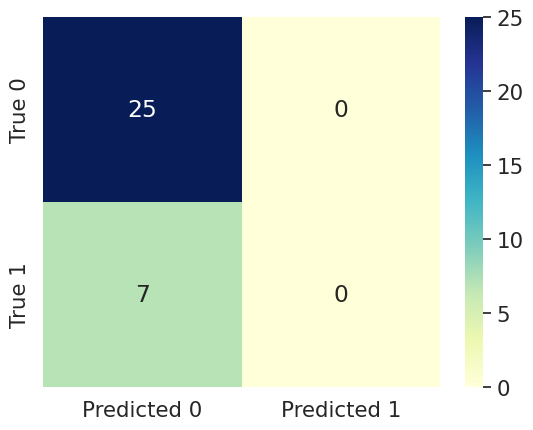

In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sn

conf_mat = metrics.confusion_matrix(true_labels, pred_labels)
df_cm = pd.DataFrame(conf_mat, ["True 0","True 1"], ["Predicted 0","Predicted 1"])

sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='d', cmap="YlGnBu")

### Testing

In [ ]:
fine_tuned_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/Colab Notebooks/sample_cl_trainer/checkpoint-40")

One review

In [ ]:
model_inputs = distilbert_tokenizer(test_review, return_tensors="pt")
prediction = torch.argmax(fine_tuned_model(**model_inputs).logits)

print(["Non-Spoiler", "Spoiler"][prediction])

Non-Spoiler


Test set

In [ ]:
trainer = Trainer(
    model=fine_tuned_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['test'], #change to test for final step
    tokenizer=distilbert_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

<ipython-input-114-221a61a70341>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.evaluate(eval_dataset=small_tokenized_dataset['test'])

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'eval_loss': 0.5169066190719604,
 'eval_model_preparation_time': 0.0035,
 'eval_accuracy': 0.78125,
 'eval_precision': 0.0,
 'eval_recall': 0.0,
 'eval_f1': 0.0,
 'eval_matthews_correlation': 0.0,
 'eval_runtime': 12.1831,
 'eval_samples_per_second': 2.627,
 'eval_steps_per_second': 0.164}